Matplotlib is building the font cache; this may take a moment.


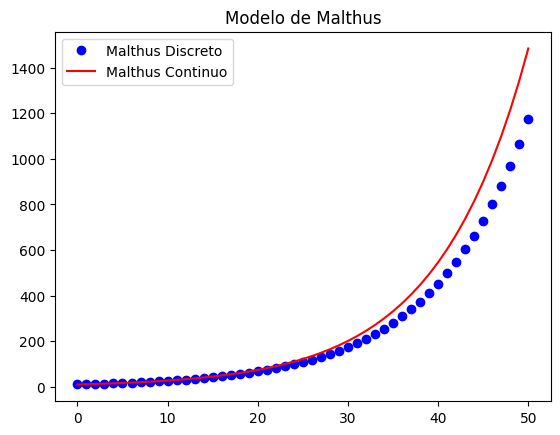

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros
x0 = 10      # Población inicial
r = 1.1      # Tasa de crecimiento (discreta)
alpha = 0.1  # Tasa de crecimiento (continua)
pasos = 50   # Cuántos años o días simularemos

# 2. Modelo Discreto (Paso a paso)
poblacion_d = [x0]
for n in range(pasos):
    nuevo_valor = r * poblacion_d[-1]
    poblacion_d.append(nuevo_valor)

# 3. Modelo Continuo (Fórmula directa)
tiempo = np.linspace(0, pasos, pasos + 1)
poblacion_c = x0 * np.exp(alpha * tiempo)

# 4. Graficar (Requisito del proyecto)
plt.plot(poblacion_d, 'bo', label="Malthus Discreto")
plt.plot(tiempo, poblacion_c, 'r-', label="Malthus Continuo")
plt.title("Modelo de Malthus")
plt.legend()
plt.show()

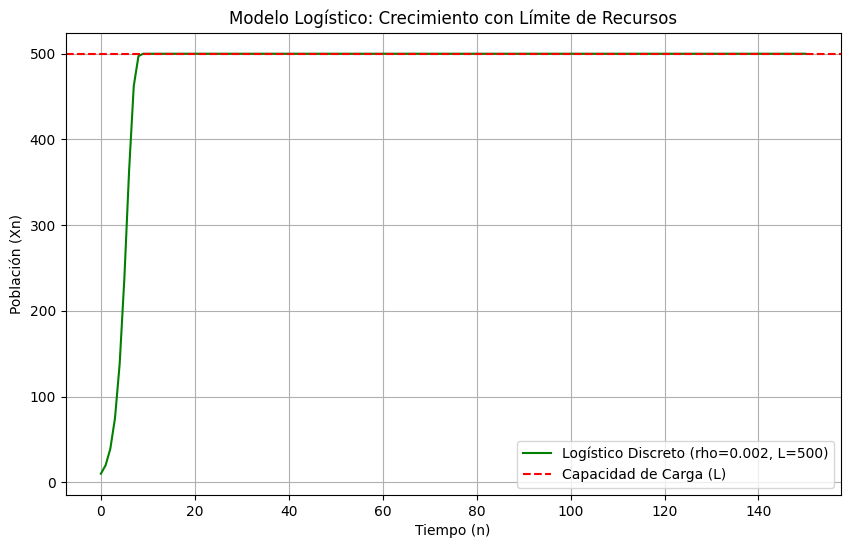

In [2]:
# 1. Parámetros del modelo logístico
x0 = 10      # Población inicial
rho = 0.002  # Tasa de crecimiento intrínseca
L = 500      # Capacidad de carga (máximo de individuos)
pasos = 150  # Simularemos más tiempo para ver cómo se estabiliza

# 2. Implementación del Modelo Logístico Discreto
# Según la fórmula: Xn+1 = Xn + rho * Xn * (L - Xn)
poblacion_log = [x0]

for n in range(pasos):
    xn = poblacion_log[-1]
    # Aplicamos la ecuación del enunciado
    xn_siguiente = xn + rho * xn * (L - xn)
    poblacion_log.append(xn_siguiente)

# 3. Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(poblacion_log, color='green', label=f"Logístico Discreto (rho={rho}, L={L})")
plt.axhline(y=L, color='r', linestyle='--', label="Capacidad de Carga (L)")
plt.title("Modelo Logístico: Crecimiento con Límite de Recursos")
plt.xlabel("Tiempo (n)")
plt.ylabel("Población (Xn)")
plt.legend()
plt.grid(True)
plt.show()

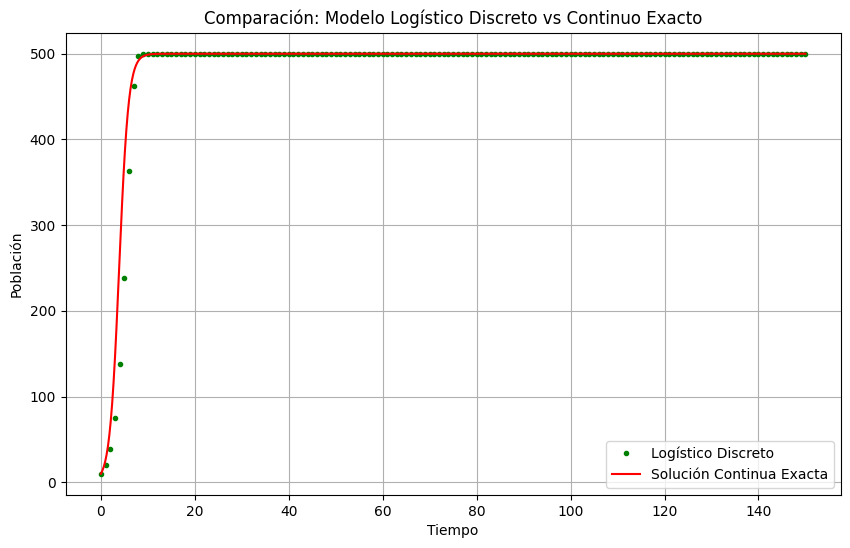

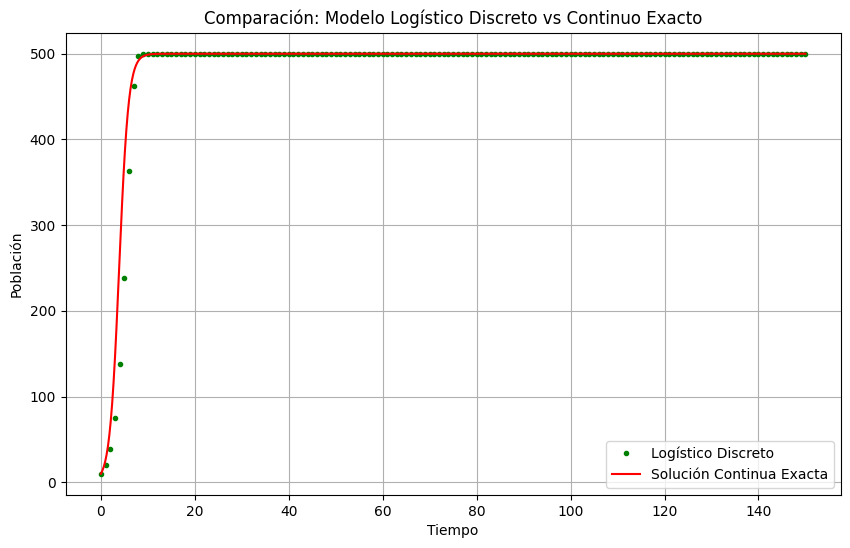

In [3]:
# 1. Definir la función de la solución exacta
def logistico_exacto(t, x0, rho, L):
    # El denominador de la fórmula
    denominador = 1 + ((L - x0) / x0) * np.exp(-rho * L * t)
    return L / denominador

# 2. Crear un arreglo de tiempo más suave para la curva continua
# Usamos más puntos (500) para que la línea se vea perfecta
t_continuo = np.linspace(0, pasos, 500)
poblacion_exacta = logistico_exacto(t_continuo, x0, rho, L)

# 3. Graficar para comparar (Requisito Fase 1.4)
plt.figure(figsize=(10, 6))
# Graficamos el discreto que ya tenían (como puntos)
plt.plot(range(len(poblacion_log)), poblacion_log, 'go', markersize=3, label="Logístico Discreto")
# Graficamos el exacto (como línea)
plt.plot(t_continuo, poblacion_exacta, 'r-', label="Solución Continua Exacta")

plt.title("Comparación: Modelo Logístico Discreto vs Continuo Exacto")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.grid(True)
plt.show()# 1. Definir la función de la solución exacta
def logistico_exacto(t, x0, rho, L):
    # El denominador de la fórmula
    denominador = 1 + ((L - x0) / x0) * np.exp(-rho * L * t)
    return L / denominador

# 2. Crear un arreglo de tiempo más suave para la curva continua
# Usamos más puntos (500) para que la línea se vea perfecta
t_continuo = np.linspace(0, pasos, 500)
poblacion_exacta = logistico_exacto(t_continuo, x0, rho, L)

# 3. Graficar para comparar (Requisito Fase 1.4)
plt.figure(figsize=(10, 6))
# Graficamos el discreto que ya tenían (como puntos)
plt.plot(range(len(poblacion_log)), poblacion_log, 'go', markersize=3, label="Logístico Discreto")
# Graficamos el exacto (como línea)
plt.plot(t_continuo, poblacion_exacta, 'r-', label="Solución Continua Exacta")

plt.title("Comparación: Modelo Logístico Discreto vs Continuo Exacto")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.grid(True)
plt.show()

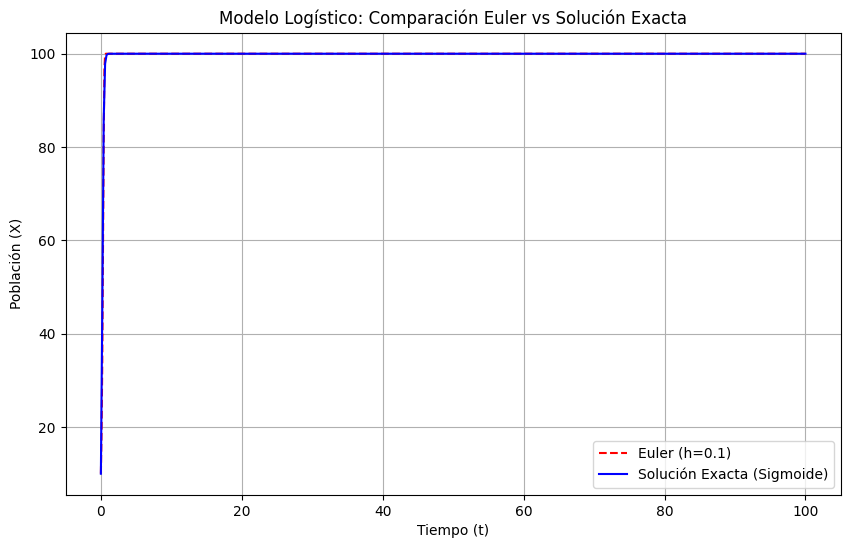

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del modelo
x0 = 10      # Población inicial
rho = 0.1    # Tasa de crecimiento
L = 100      # Capacidad de carga
t_final = 100
h = 0.1      # Tamaño del paso para Euler
n_pasos = int(t_final / h)

# --- IMPLEMENTACIÓN MÉTODO DE EULER (Punto 3) ---
t_euler = np.linspace(0, t_final, n_pasos + 1)
x_euler = np.zeros(n_pasos + 1)
x_euler[0] = x0

for n in range(n_pasos):
    # EDO Logística: dX/dt = rho * X * (L - X)
    derivada = rho * x_euler[n] * (L - x_euler[n])
    x_euler[n+1] = x_euler[n] + h * derivada

# --- SOLUCIÓN CONTINUA EXACTA (Para comparar) ---
t_exacta = np.linspace(0, t_final, 500)
x_exacta = L / (1 + ((L - x0) / x0) * np.exp(-rho * L * t_exacta))

# --- GENERACIÓN DE GRÁFICOS (Punto 4) ---
plt.figure(figsize=(10, 6))

# Graficar Euler
plt.plot(t_euler, x_euler, 'r--', label=f'Euler (h={h})')
# Graficar Exacta
plt.plot(t_exacta, x_exacta, 'b-', label='Solución Exacta (Sigmoide)')

plt.title('Modelo Logístico: Comparación Euler vs Solución Exacta')
plt.xlabel('Tiempo (t)')
plt.ylabel('Población (X)')
plt.legend()
plt.grid(True)
plt.show()

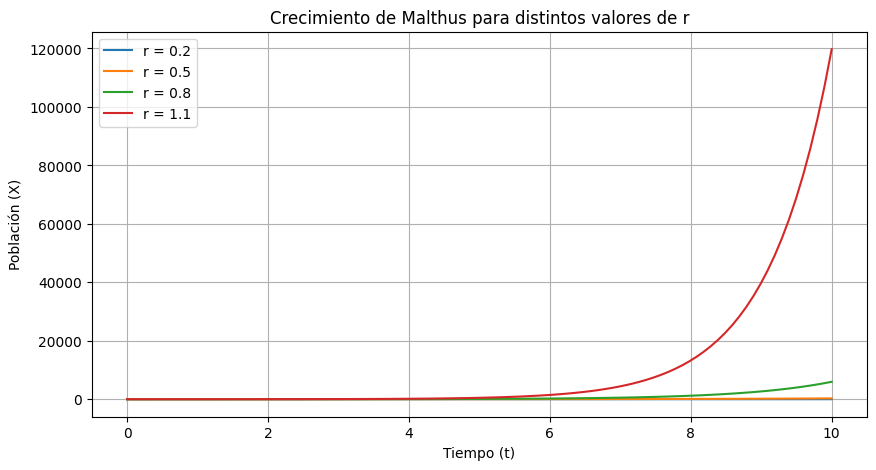

C:\Users\Vicen\AppData\Local\Temp\ipykernel_2736\2890373223.py:34: RuntimeWarning: overflow encountered in scalar multiply
  x_disc[n+1] = x_disc[n] + rho_discreto * x_disc[n] * (L - x_disc[n])


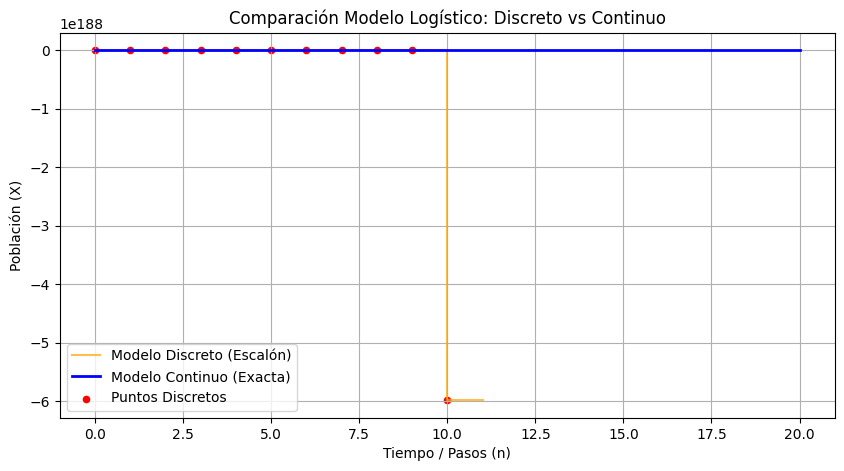

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CURVAS DE MALTHUS PARA DISTINTOS r (Punto 4) ---
t = np.linspace(0, 10, 100)
x0 = 2
tasas_r = [0.2, 0.5, 0.8, 1.1]

plt.figure(figsize=(10, 5))
for r in tasas_r:
    # Modelo continuo de Malthus: X(t) = X0 * e^(rt)
    x_malthus = x0 * np.exp(r * t)
    plt.plot(t, x_malthus, label=f'r = {r}')

plt.title('Crecimiento de Malthus para distintos valores de r')
plt.xlabel('Tiempo (t)')
plt.ylabel('Población (X)')
plt.legend()
plt.grid(True)
plt.show()

# --- 2. COMPARACIÓN DISCRETO VS CONTINUO (Punto 4) ---
# Parámetros para la comparación
L = 100
rho_discreto = 0.05
x0 = 10
pasos = 20
n_it = np.arange(pasos + 1)

# Logístico Discreto: Xn+1 = Xn + rho * Xn * (L - Xn)
x_disc = np.zeros(pasos + 1)
x_disc[0] = x0
for n in range(pasos):
    x_disc[n+1] = x_disc[n] + rho_discreto * x_disc[n] * (L - x_disc[n])

# Logístico Continuo (Solución Exacta)
t_cont = np.linspace(0, pasos, 100)
# Para que coincidan, usamos rho_continuo aproximado
x_cont = L / (1 + ((L - x0) / x0) * np.exp(-rho_discreto * L * t_cont))

plt.figure(figsize=(10, 5))
plt.step(n_it, x_disc, where='post', label='Modelo Discreto (Escalón)', color='orange', alpha=0.7)
plt.plot(t_cont, x_cont, 'b-', label='Modelo Continuo (Exacta)', linewidth=2)
plt.scatter(n_it, x_disc, color='red', s=20, label='Puntos Discretos')

plt.title('Comparación Modelo Logístico: Discreto vs Continuo')
plt.xlabel('Tiempo / Pasos (n)')
plt.ylabel('Población (X)')
plt.legend()
plt.grid(True)
plt.show()